# `qufin.options` Tutorial

An end-to-end walkthrough of the **options** subpackage:

1. Pricing & greeks (Black-Scholes, vectorised + numba)
2. Implied volatility solver round-trip
3. Building an `OptionChain` from synthetic data
4. **Gamma-Exposure (GEX) analytics** — per-strike exposure, gamma flip, walls, max-pain
5. GEX profile sweep — "if spot moves to X, dealers must hedge by Y"
6. **Backtest #1** — long-gamma vs short-gamma regime switching (mean-revert vs trend)
7. **Backtest #2** — zero-gamma flip breakout

All data here is synthetic so the notebook runs offline. Swap in `load_chain_yfinance("SPY")` to point any of these analytics at real chains.


In [1]:
from __future__ import annotations

from datetime import date, timedelta

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from qufin.options import (
    CALL,
    PUT,
    OptionChain,
    aggregate_exposure,
    black_scholes_greeks,
    black_scholes_price,
    call_wall,
    gex_profile,
    implied_vol,
    max_pain,
    put_wall,
    zero_gamma_level,
)

plt.rcParams.update({
    'figure.figsize': (11, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

rng = np.random.default_rng(42)


## 1. Black-Scholes pricing & greeks

Every numerical hot path is a `@numba.njit(parallel=True)` kernel, so the public API just brokers arrays into the kernel and returns either a scalar (when all inputs are scalars) or an `np.ndarray`.


Call price: 10.4506


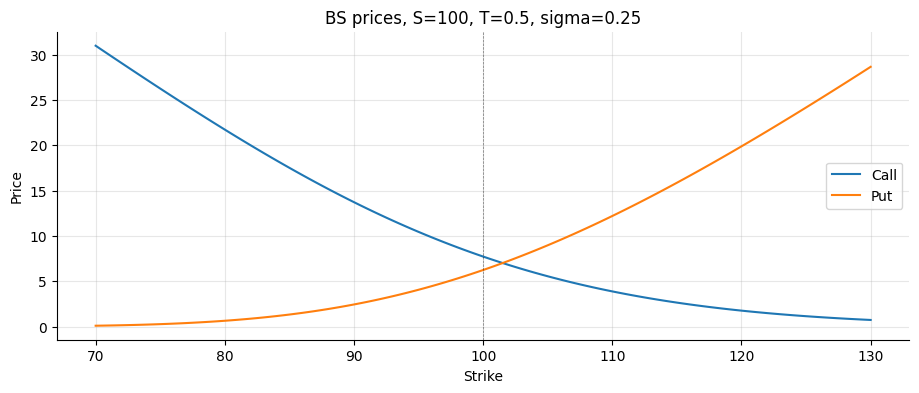

In [2]:
p = black_scholes_price(S=100.0, K=100.0, T=1.0, r=0.05, q=0.0, sigma=0.20, option_type='C')
print(f'Call price: {p:.4f}')

K = np.linspace(70, 130, 121)
n = K.shape[0]
calls = black_scholes_price(
    S=np.full(n, 100.0), K=K, T=np.full(n, 0.5),
    r=np.full(n, 0.04), q=np.full(n, 0.01),
    sigma=np.full(n, 0.25), option_type='C',
)
puts = black_scholes_price(
    S=np.full(n, 100.0), K=K, T=np.full(n, 0.5),
    r=np.full(n, 0.04), q=np.full(n, 0.01),
    sigma=np.full(n, 0.25), option_type='P',
)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(K, calls, label='Call')
ax.plot(K, puts, label='Put')
ax.axvline(100, color='k', lw=0.5, ls='--', alpha=0.5)
ax.set(xlabel='Strike', ylabel='Price', title='BS prices, S=100, T=0.5, sigma=0.25')
ax.legend(); plt.show()


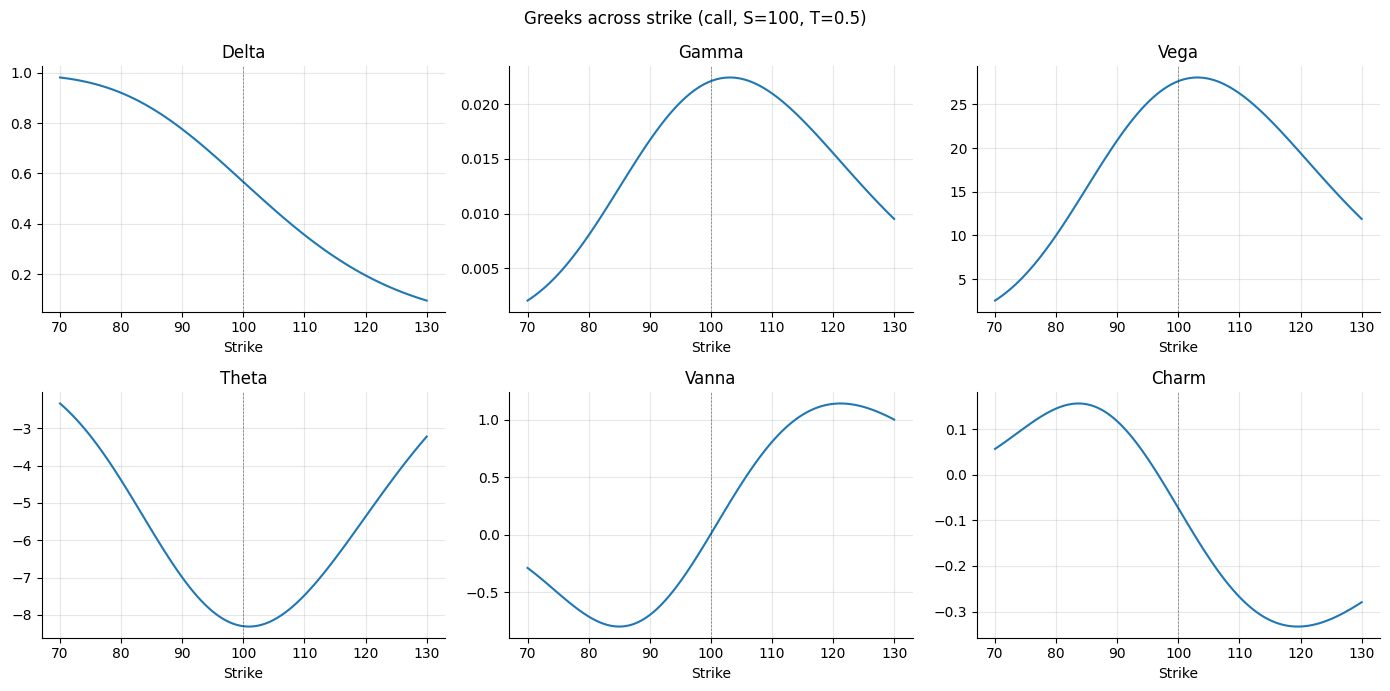

In [3]:
g = black_scholes_greeks(
    S=np.full(n, 100.0), K=K, T=np.full(n, 0.5),
    r=np.full(n, 0.04), q=np.full(n, 0.01),
    sigma=np.full(n, 0.25), option_type='C',
)

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
panels = [('Delta', g.delta), ('Gamma', g.gamma), ('Vega', g.vega),
          ('Theta', g.theta), ('Vanna', g.vanna), ('Charm', g.charm)]
for ax, (name, arr) in zip(axes.flat, panels):
    ax.plot(K, arr)
    ax.axvline(100, color='k', lw=0.5, ls='--', alpha=0.5)
    ax.set(title=name, xlabel='Strike')
plt.suptitle('Greeks across strike (call, S=100, T=0.5)')
plt.tight_layout(); plt.show()


## 2. Implied volatility round-trip

The solver is Newton-Raphson with bisection fallback, seeded by the Manaster-Koehler initial guess. Tail strikes with sub-penny prices may return `NaN` — vega vanishes there and IV is genuinely indeterminate.


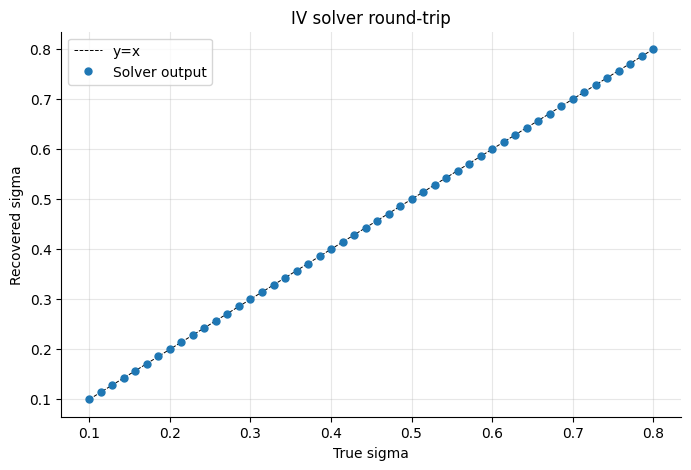

Max abs error: 1.96e-10


In [4]:
true_sigma = np.linspace(0.10, 0.80, 50)
K_grid = np.full_like(true_sigma, 100.0)
S_grid = np.full_like(true_sigma, 100.0)
T_grid = np.full_like(true_sigma, 0.5)

prices = black_scholes_price(
    S=S_grid, K=K_grid, T=T_grid,
    r=np.full_like(true_sigma, 0.0),
    q=np.full_like(true_sigma, 0.0),
    sigma=true_sigma, option_type='C',
)
recovered = implied_vol(
    price=prices, S=S_grid, K=K_grid, T=T_grid,
    r=0.0, q=0.0, option_type='C',
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(true_sigma, true_sigma, 'k--', lw=0.7, label='y=x')
ax.plot(true_sigma, recovered, 'o', ms=5, label='Solver output')
ax.set(xlabel='True sigma', ylabel='Recovered sigma', title='IV solver round-trip')
ax.legend(); plt.show()
print(f'Max abs error: {np.nanmax(np.abs(recovered - true_sigma)):.2e}')


## 3. Building a synthetic `OptionChain`

`OptionChain` wraps a polars DataFrame with the canonical schema. The factory `OptionChain.from_records` coerces column dtypes so downstream code is source-agnostic.

Below we build a multi-expiry chain with an SPX-like OI distribution:
- **Puts** — open interest peaks at ~95% of spot (classic put protection)
- **Calls** — open interest peaks at ~105% of spot (covered-call / yield-trade region)


In [5]:
def synthetic_chain(
    *,
    spot: float = 4500.0,
    as_of: date = date(2026, 5, 17),
    expiries_days: tuple[int, ...] = (7, 30, 60),
    base_iv: float = 0.18,
    skew: float = 0.50,
    put_oi_peak_pct: float = 0.95,
    call_oi_peak_pct: float = 1.05,
    oi_width_pct: float = 0.04,
    oi_scale: float = 30_000.0,
) -> OptionChain:
    strikes = np.arange(spot * 0.85, spot * 1.15 + 1.0, 25.0)
    rows: list[dict] = []
    for d in expiries_days:
        expiry = as_of + timedelta(days=d)
        T = d / 365.25
        for K in strikes:
            log_m = np.log(K / spot) / max(np.sqrt(T), 1e-3)
            iv = max(base_iv - skew * log_m + 0.5 * skew * log_m**2, 0.05)
            put_oi = oi_scale * np.exp(
                -0.5 * ((K - spot * put_oi_peak_pct) / (oi_width_pct * spot)) ** 2
            )
            call_oi = oi_scale * np.exp(
                -0.5 * ((K - spot * call_oi_peak_pct) / (oi_width_pct * spot)) ** 2
            )
            for side, oi_val in ((CALL, call_oi), (PUT, put_oi)):
                rows.append({
                    'expiry': expiry,
                    'strike': float(K),
                    'option_type': side,
                    'bid': 0.0, 'ask': 0.0, 'last': 0.0,
                    'volume': 0,
                    'open_interest': int(oi_val),
                    'iv': float(iv),
                })
    return OptionChain.from_records(
        pl.DataFrame(rows),
        spot=spot, as_of=as_of, underlying='SPX_SYN',
        r=0.045, q=0.013,
    )

chain = synthetic_chain()
n_exp = chain.data['expiry'].n_unique()
print(f'Spot: {chain.spot:.2f}, contracts: {chain.data.height}, expiries: {n_exp}')
chain.data.head(6)


Spot: 4500.00, contracts: 330, expiries: 3


expiry,strike,option_type,bid,ask,last,volume,open_interest,iv
date,f64,str,f64,f64,f64,i64,i64,f64
2026-05-24,3825.0,"""C""",0.0,0.0,0.0,0,0,1.111516
2026-05-24,3825.0,"""P""",0.0,0.0,0.0,0,1318,1.111516
2026-05-24,3850.0,"""C""",0.0,0.0,0.0,0,0,1.060918
2026-05-24,3850.0,"""P""",0.0,0.0,0.0,0,1847,1.060918
2026-05-24,3875.0,"""C""",0.0,0.0,0.0,0,0,1.011744
2026-05-24,3875.0,"""P""",0.0,0.0,0.0,0,2539,1.011744


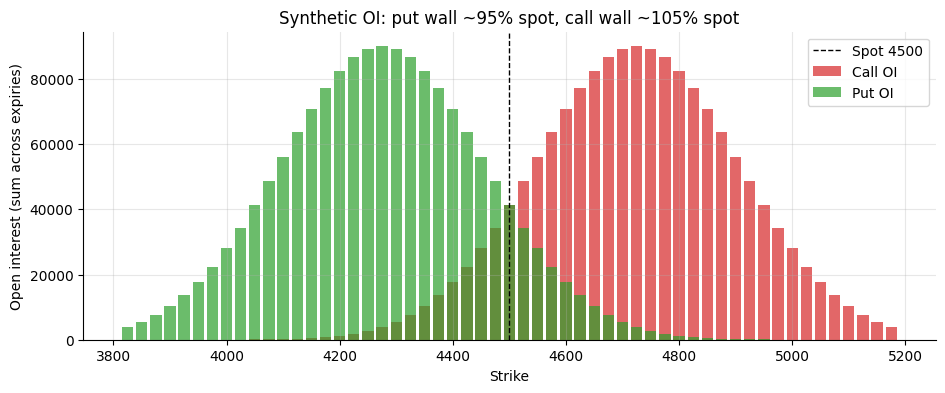

In [6]:
df = chain.data.group_by(['strike', 'option_type']).agg(
    pl.col('open_interest').sum()
).sort('strike')
calls_df = df.filter(pl.col('option_type') == CALL)
puts_df = df.filter(pl.col('option_type') == PUT)

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(calls_df['strike'], calls_df['open_interest'], width=20, alpha=0.7, label='Call OI', color='tab:red')
ax.bar(puts_df['strike'], puts_df['open_interest'], width=20, alpha=0.7, label='Put OI', color='tab:green')
ax.axvline(chain.spot, color='k', lw=1, ls='--', label=f'Spot {chain.spot:.0f}')
ax.set(xlabel='Strike', ylabel='Open interest (sum across expiries)',
       title='Synthetic OI: put wall ~95% spot, call wall ~105% spot')
ax.legend(); plt.show()


## 4. Per-strike dealer exposure

`aggregate_exposure` returns a `StrikeExposure` with **dealer GEX/DEX/VEX/charm** aggregated across all expiries, in dollars per 1% spot move.

Under `DealerConvention.CLASSIC`:
- Dealers are **short calls** (gamma contribution negative)
- Dealers are **long puts** (gamma contribution positive)

Total GEX < 0 means dealers must trend-amplify (sell low / buy high). Total GEX > 0 means dealers must mean-revert (buy low / sell high).


Total dealer GEX: $4,909,561,498 per 1% move
Total dealer DEX: $-331,891,297,701


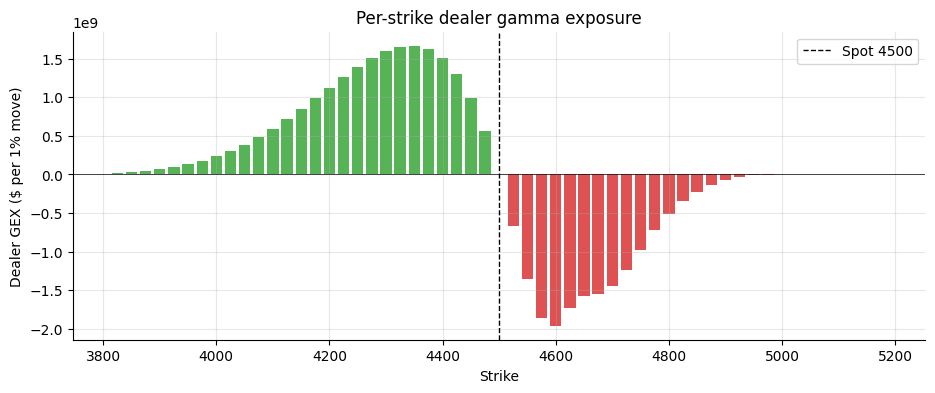

In [7]:
exposure = aggregate_exposure(chain)
print(f"Total dealer GEX: ${exposure.notes['total_gex']:,.0f} per 1% move")
print(f"Total dealer DEX: ${exposure.notes['total_dex']:,.0f}")

fig, ax = plt.subplots(figsize=(11, 4))
colors = np.where(exposure.gex >= 0, 'tab:green', 'tab:red')
ax.bar(exposure.strikes, exposure.gex, width=20, color=colors, alpha=0.8)
ax.axvline(chain.spot, color='k', lw=1, ls='--', label=f'Spot {chain.spot:.0f}')
ax.axhline(0, color='k', lw=0.5)
ax.set(xlabel='Strike', ylabel='Dealer GEX ($ per 1% move)',
       title='Per-strike dealer gamma exposure')
ax.legend(); plt.show()


## 5. Gamma flip, walls, max-pain

- **Zero-gamma level** — spot at which aggregate dealer gamma changes sign. Above it dealers dampen moves; below it they amplify them.
- **Call wall** — strike with the deepest negative dealer GEX (resistance).
- **Put wall** — strike with the deepest positive dealer GEX (support).
- **Max-pain** — strike that minimises aggregate option-holder payoff at expiry.


Spot:           4500.00
Zero-gamma flip: 4528.03
Call wall:      4575.00
Put wall:       4425.00
Max-pain:       4500.00


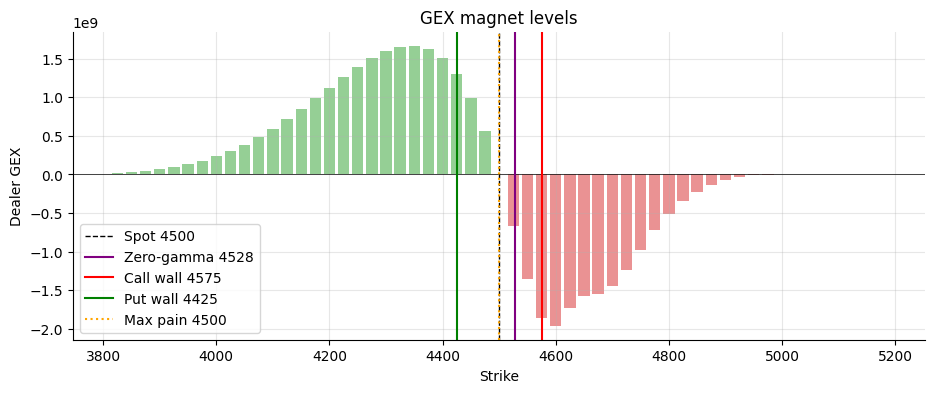

In [8]:
flip = zero_gamma_level(chain, search_pct=0.15, n_grid=801)
cw = call_wall(chain)
pw = put_wall(chain)
mp = max_pain(chain)

print(f'Spot:           {chain.spot:.2f}')
print('Zero-gamma flip:' + (f' {flip:.2f}' if flip is not None else ' not found in range'))
print(f'Call wall:      {cw:.2f}')
print(f'Put wall:       {pw:.2f}')
print(f'Max-pain:       {mp:.2f}')

fig, ax = plt.subplots(figsize=(11, 4))
colors = np.where(exposure.gex >= 0, 'tab:green', 'tab:red')
ax.bar(exposure.strikes, exposure.gex, width=20, color=colors, alpha=0.5)
ax.axhline(0, color='k', lw=0.5)
ax.axvline(chain.spot, color='k', ls='--', lw=1, label=f'Spot {chain.spot:.0f}')
if flip is not None:
    ax.axvline(flip, color='purple', lw=1.5, label=f'Zero-gamma {flip:.0f}')
ax.axvline(cw, color='red', lw=1.5, label=f'Call wall {cw:.0f}')
ax.axvline(pw, color='green', lw=1.5, label=f'Put wall {pw:.0f}')
ax.axvline(mp, color='orange', lw=1.5, ls=':', label=f'Max pain {mp:.0f}')
ax.set(xlabel='Strike', ylabel='Dealer GEX', title='GEX magnet levels')
ax.legend(loc='lower left'); plt.show()


## 6. GEX profile across a spot grid

`gex_profile` sweeps a hypothetical spot range and recomputes dealer GEX/DEX/VEX/charm at every level. The output answers questions like *'if SPX rallies 2%, how much does dealer delta change?'*


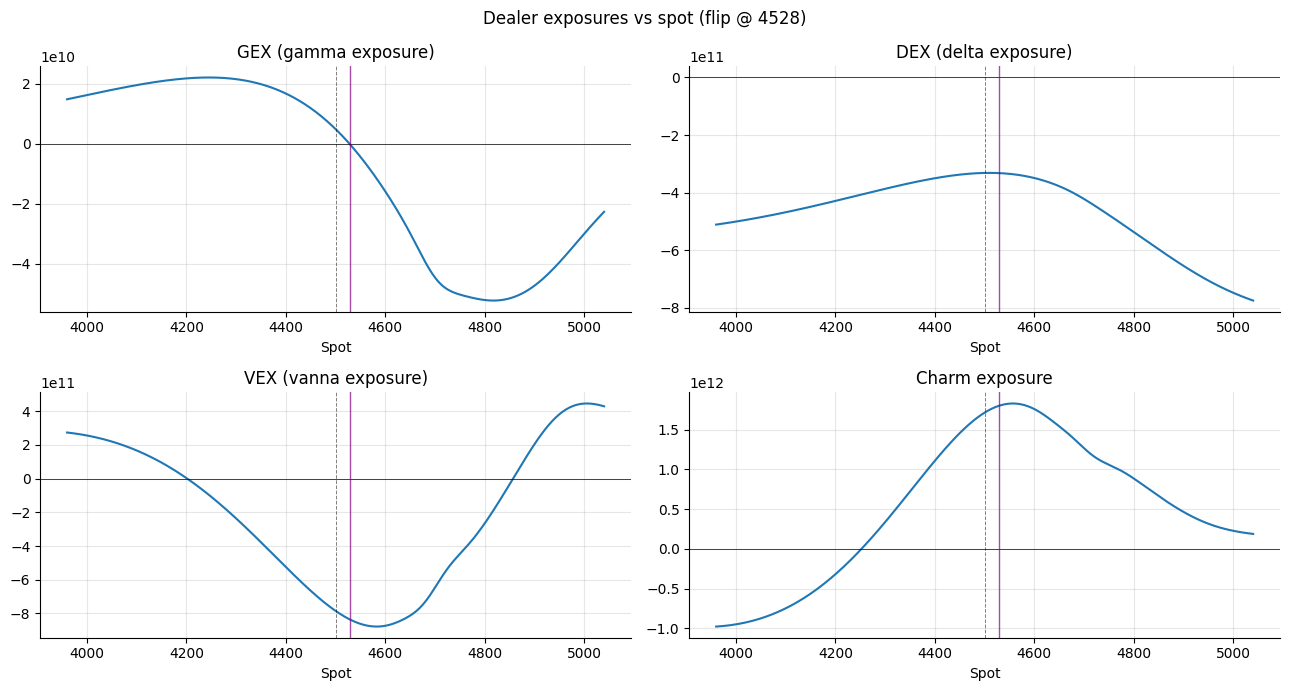

In [9]:
profile = gex_profile(chain, n_spot=301, spot_range_pct=0.12)

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
panels = [
    ('GEX (gamma exposure)', profile.gex),
    ('DEX (delta exposure)', profile.dex),
    ('VEX (vanna exposure)', profile.vex),
    ('Charm exposure', profile.charm),
]
for ax, (name, arr) in zip(axes.flat, panels):
    ax.plot(profile.spot_grid, arr)
    ax.axhline(0, color='k', lw=0.5)
    ax.axvline(chain.spot, color='k', ls='--', lw=0.7, alpha=0.5)
    if profile.flip_level is not None:
        ax.axvline(profile.flip_level, color='purple', lw=1, alpha=0.7)
    ax.set(title=name, xlabel='Spot')
title = 'Dealer exposures vs spot'
if profile.flip_level is not None:
    title += f' (flip @ {profile.flip_level:.0f})'
plt.suptitle(title)
plt.tight_layout(); plt.show()


## 7. Backtest #1 — long-gamma vs short-gamma regime switching

**Trading hypothesis:** when aggregate dealer GEX is positive, hedging flow is mean-reverting — fade the move. When GEX is negative, hedging is trend-amplifying — go with the move.

**Setup**
- Simulate SPX-like underlying as a daily GBM path.
- Re-evaluate the chain at every step (strikes & OI fixed, spot moves, T decays).
- Compute total dealer GEX.
- **Signal:** `position = +sign(yesterday's return)` when GEX < 0, `-sign(yesterday's return)` when GEX > 0.
- **PnL:** `position[t] * spot_return[t+1]`.

Strategy is intentionally toy — the goal is to demonstrate the API, not to make money.


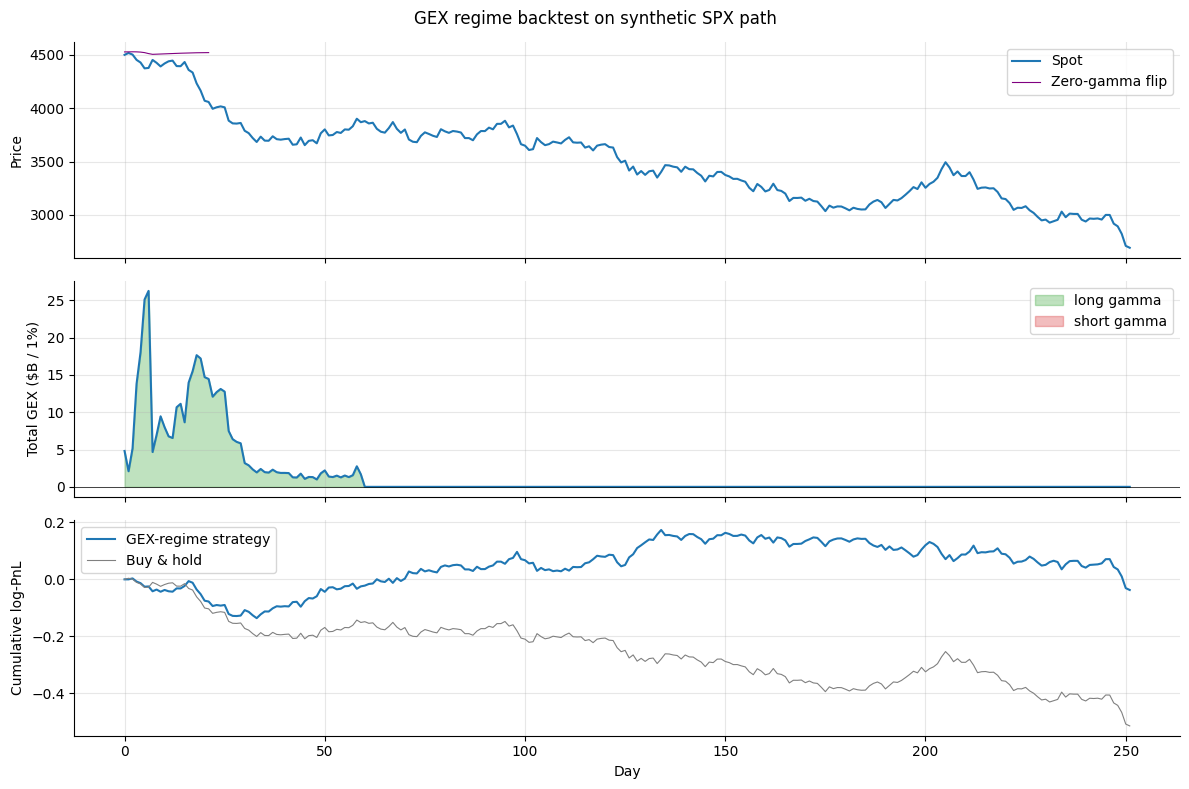

Strategy Sharpe (synth): -0.20
Days in long-gamma regime: 252 / 252


In [10]:
def simulate_path(*, n_days: int = 252, S0: float = 4500.0,
                  mu: float = 0.05, sigma: float = 0.18, seed: int = 1):
    rng_local = np.random.default_rng(seed)
    dt = 1.0 / 252.0
    eps = rng_local.standard_normal(n_days)
    log_ret = (mu - 0.5 * sigma * sigma) * dt + sigma * np.sqrt(dt) * eps
    return S0 * np.exp(np.cumsum(log_ret))

def refresh_chain(template: OptionChain, *, spot: float, as_of: date) -> OptionChain:
    return OptionChain(
        data=template.data,
        spot=spot, as_of=as_of,
        underlying=template.underlying,
        r=template.r, q=template.q, multiplier=template.multiplier,
    )

n_days = 252
path = simulate_path(n_days=n_days, S0=4500.0, mu=0.05, sigma=0.20, seed=7)
as_of_start = date(2026, 5, 17)
template = synthetic_chain(spot=4500.0, as_of=as_of_start)

total_gex = np.zeros(n_days)
flip_path = np.zeros(n_days)
for t in range(n_days):
    snap = refresh_chain(template, spot=path[t], as_of=as_of_start + timedelta(days=t))
    total_gex[t] = aggregate_exposure(snap).notes['total_gex']
    fl = zero_gamma_level(snap, search_pct=0.12, n_grid=201)
    flip_path[t] = fl if fl is not None else np.nan

ret = np.diff(np.log(path), prepend=np.log(path[0]))
regime = np.where(total_gex >= 0, +1.0, -1.0)
prev_ret_sign = np.sign(np.roll(ret, 1))
prev_ret_sign[0] = 0.0
position = np.where(regime > 0, -prev_ret_sign, prev_ret_sign)
pnl_daily = position * ret
pnl_cum = np.cumsum(pnl_daily)
bench = np.cumsum(ret)

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axes[0].plot(path, label='Spot')
axes[0].plot(flip_path, label='Zero-gamma flip', color='purple', lw=0.8)
axes[0].set_ylabel('Price'); axes[0].legend()
axes[1].plot(total_gex / 1e9, color='tab:blue')
axes[1].axhline(0, color='k', lw=0.5)
days = np.arange(n_days)
axes[1].fill_between(days, 0, total_gex / 1e9,
                     where=total_gex >= 0, color='tab:green', alpha=0.3, label='long gamma')
axes[1].fill_between(days, 0, total_gex / 1e9,
                     where=total_gex < 0, color='tab:red', alpha=0.3, label='short gamma')
axes[1].set_ylabel('Total GEX ($B / 1%)'); axes[1].legend()
axes[2].plot(pnl_cum, label='GEX-regime strategy')
axes[2].plot(bench, label='Buy & hold', color='grey', lw=0.8)
axes[2].set_ylabel('Cumulative log-PnL'); axes[2].set_xlabel('Day'); axes[2].legend()
plt.suptitle('GEX regime backtest on synthetic SPX path')
plt.tight_layout(); plt.show()

sharpe = np.sqrt(252) * pnl_daily.mean() / (pnl_daily.std() + 1e-12)
print(f'Strategy Sharpe (synth): {sharpe:.2f}')
print(f'Days in long-gamma regime: {(regime > 0).sum()} / {n_days}')


## 8. Backtest #2 — zero-gamma flip breakout

**Trading hypothesis:** the zero-gamma level acts as a pivot. A clean break above it confirms a positive-gamma regime (calmer, drift-up tendency); a break below confirms a short-gamma regime (vol expansion).

**Signal:** go long when *yesterday's* spot closed above the flip, short when below.


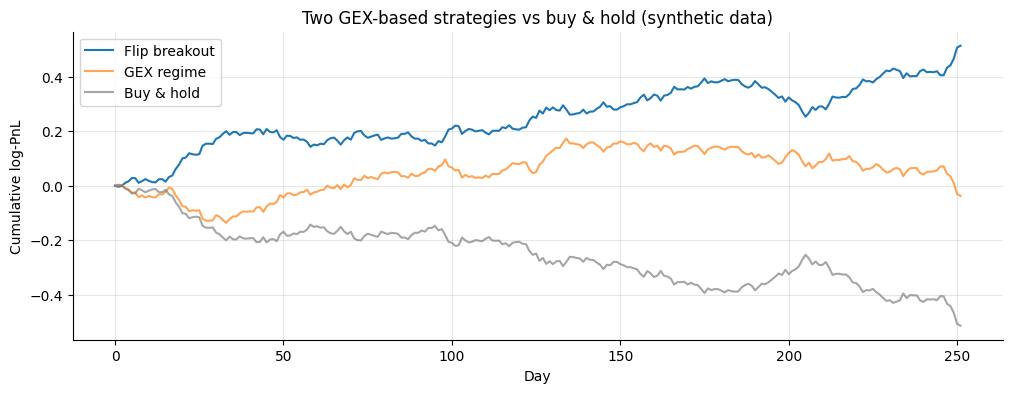

Flip strategy Sharpe (synth): 2.79


In [11]:
above_flip = path > flip_path
flip_signal = np.where(np.roll(above_flip, 1), +1.0, -1.0)
flip_signal[0] = 0.0
pnl_flip = flip_signal * ret
cum_flip = np.cumsum(pnl_flip)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(cum_flip, label='Flip breakout')
ax.plot(pnl_cum, label='GEX regime', alpha=0.7)
ax.plot(bench, label='Buy & hold', color='grey', alpha=0.7)
ax.set(xlabel='Day', ylabel='Cumulative log-PnL',
       title='Two GEX-based strategies vs buy & hold (synthetic data)')
ax.legend(); plt.show()

sharpe_flip = np.sqrt(252) * pnl_flip.mean() / (pnl_flip.std() + 1e-12)
print(f'Flip strategy Sharpe (synth): {sharpe_flip:.2f}')


## 9. Where to go from here

- Swap synthetic chains for real ones: `qufin.options.data.load_chain_yfinance("SPY")`.
- Plug your own provider into `qufin/options/data/` — emit the canonical schema and everything downstream just works.
- Use `DealerConvention.CUSTOM` with a per-contract `dealer_signs` array if you have intraday OI-flow data that beats the SqueezeMetrics heuristic.
- Replace the toy strategies with proper portfolio sizing, transaction costs, and out-of-sample windows (see `qufin.timeseries.forecast_eval.RollingBacktest`).
- The numba kernels release the GIL — embed them in async data pipelines without blocking.
